# Programming with Python - CIA3
Submitted by Diwakar(2527216)

## 1. INTRODUCTION

### Why is a Placement Management System required?

Campus placements are one of the most critical milestones in a student's academic journey. For colleges and universities, managing the entire placement process from company registrations and job postings to student applications, interview scheduling, and offer letter distribution is an enormously complex and time-sensitive operation.

Currently, most placement cells rely on spreadsheets, emails, and manual coordination to manage hundreds of students and dozens of companies simultaneously. This leads to miscommunication, missed deadlines, data inconsistencies, and a lack of transparency for students who are anxious about their placement status. Placement officers are overburdened with repetitive administrative tasks, and companies often face delays in receiving shortlisted candidate information.

A dedicated Placement Management System like CampusHire addresses these challenges by providing a centralized, structured platform to manage the entire recruitment lifecycle. It enables students to view openings and track their applications in real time, allows placement officers to coordinate companies and interview rounds efficiently, and gives administrators full visibility and control over the process. By automating routine tasks and organizing data systematically, CampusHire saves time, reduces errors, and significantly improves the placement experience for all stakeholders.

### Problem Statement:

Students and placement officers at educational institutions struggle to manage the campus recruitment process efficiently due to a lack of centralized tooling. Manual tracking of job postings, applications, interview rounds, and offer letters leads to data loss, miscommunication, and poor candidate experience. There is a need for a structured, role-based placement management system that streamlines the end-to-end recruitment workflow from company onboarding and job posting to offer letter generation enabling students, placement officers, and administrators to operate from a single, unified platform.

## 2. E-R Diagram

![ER Diagram.png](<attachment:ER Diagram.png>)
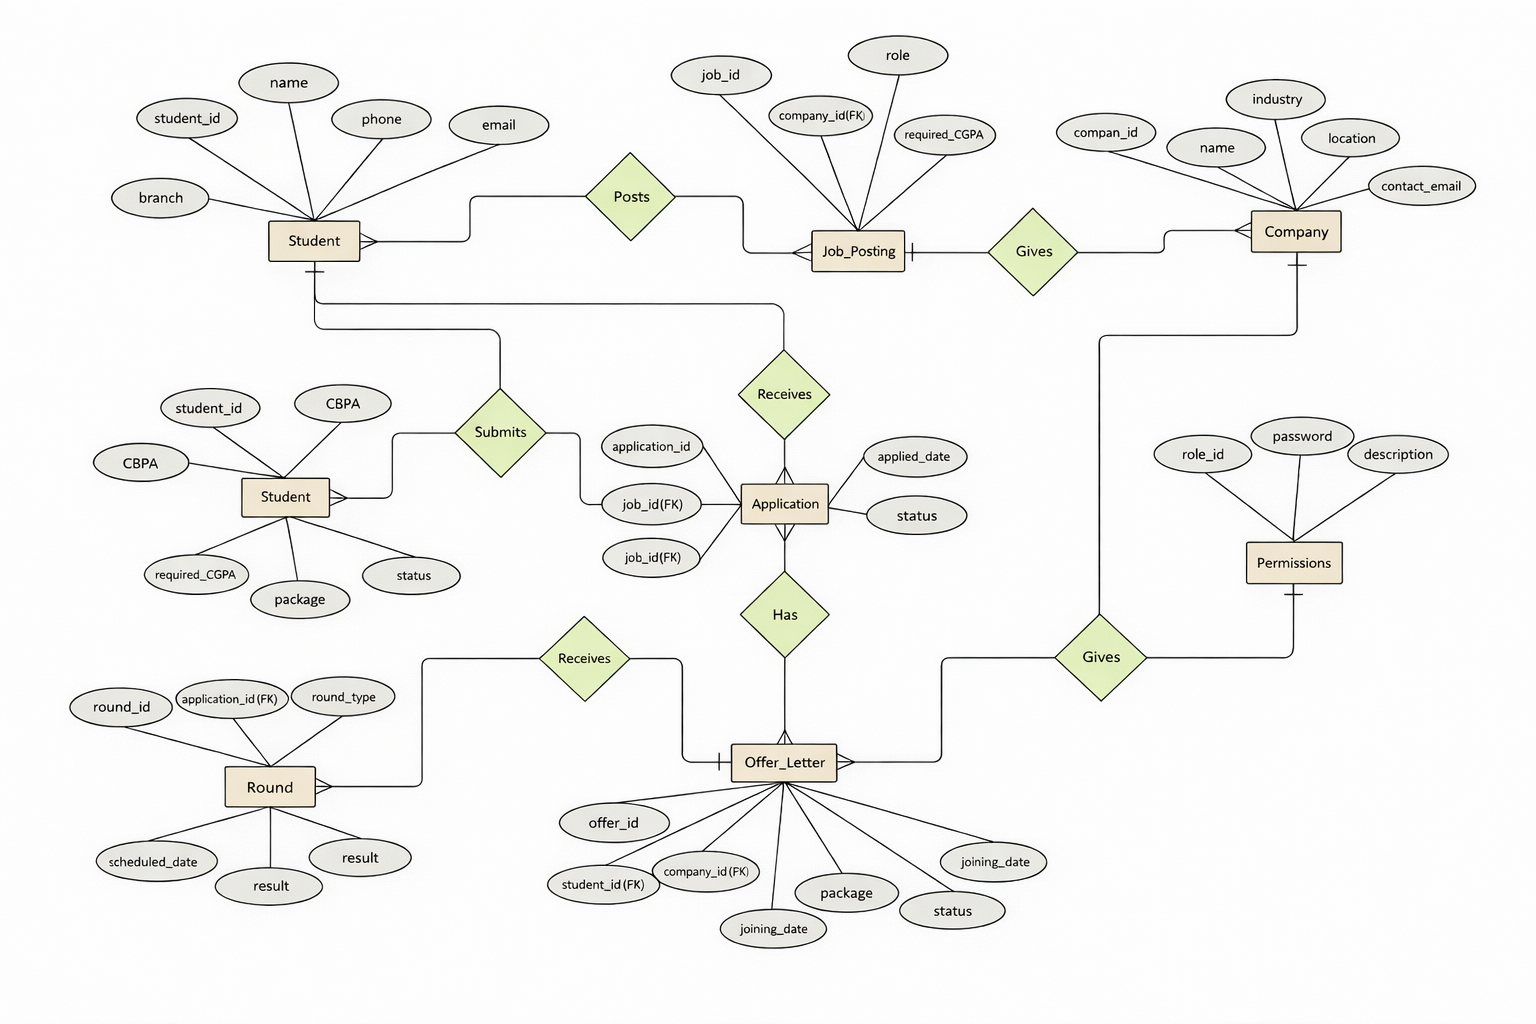

## 3. Process Flow Diagram

![Flow Chart.png](<attachment:Flow Chart.png>)
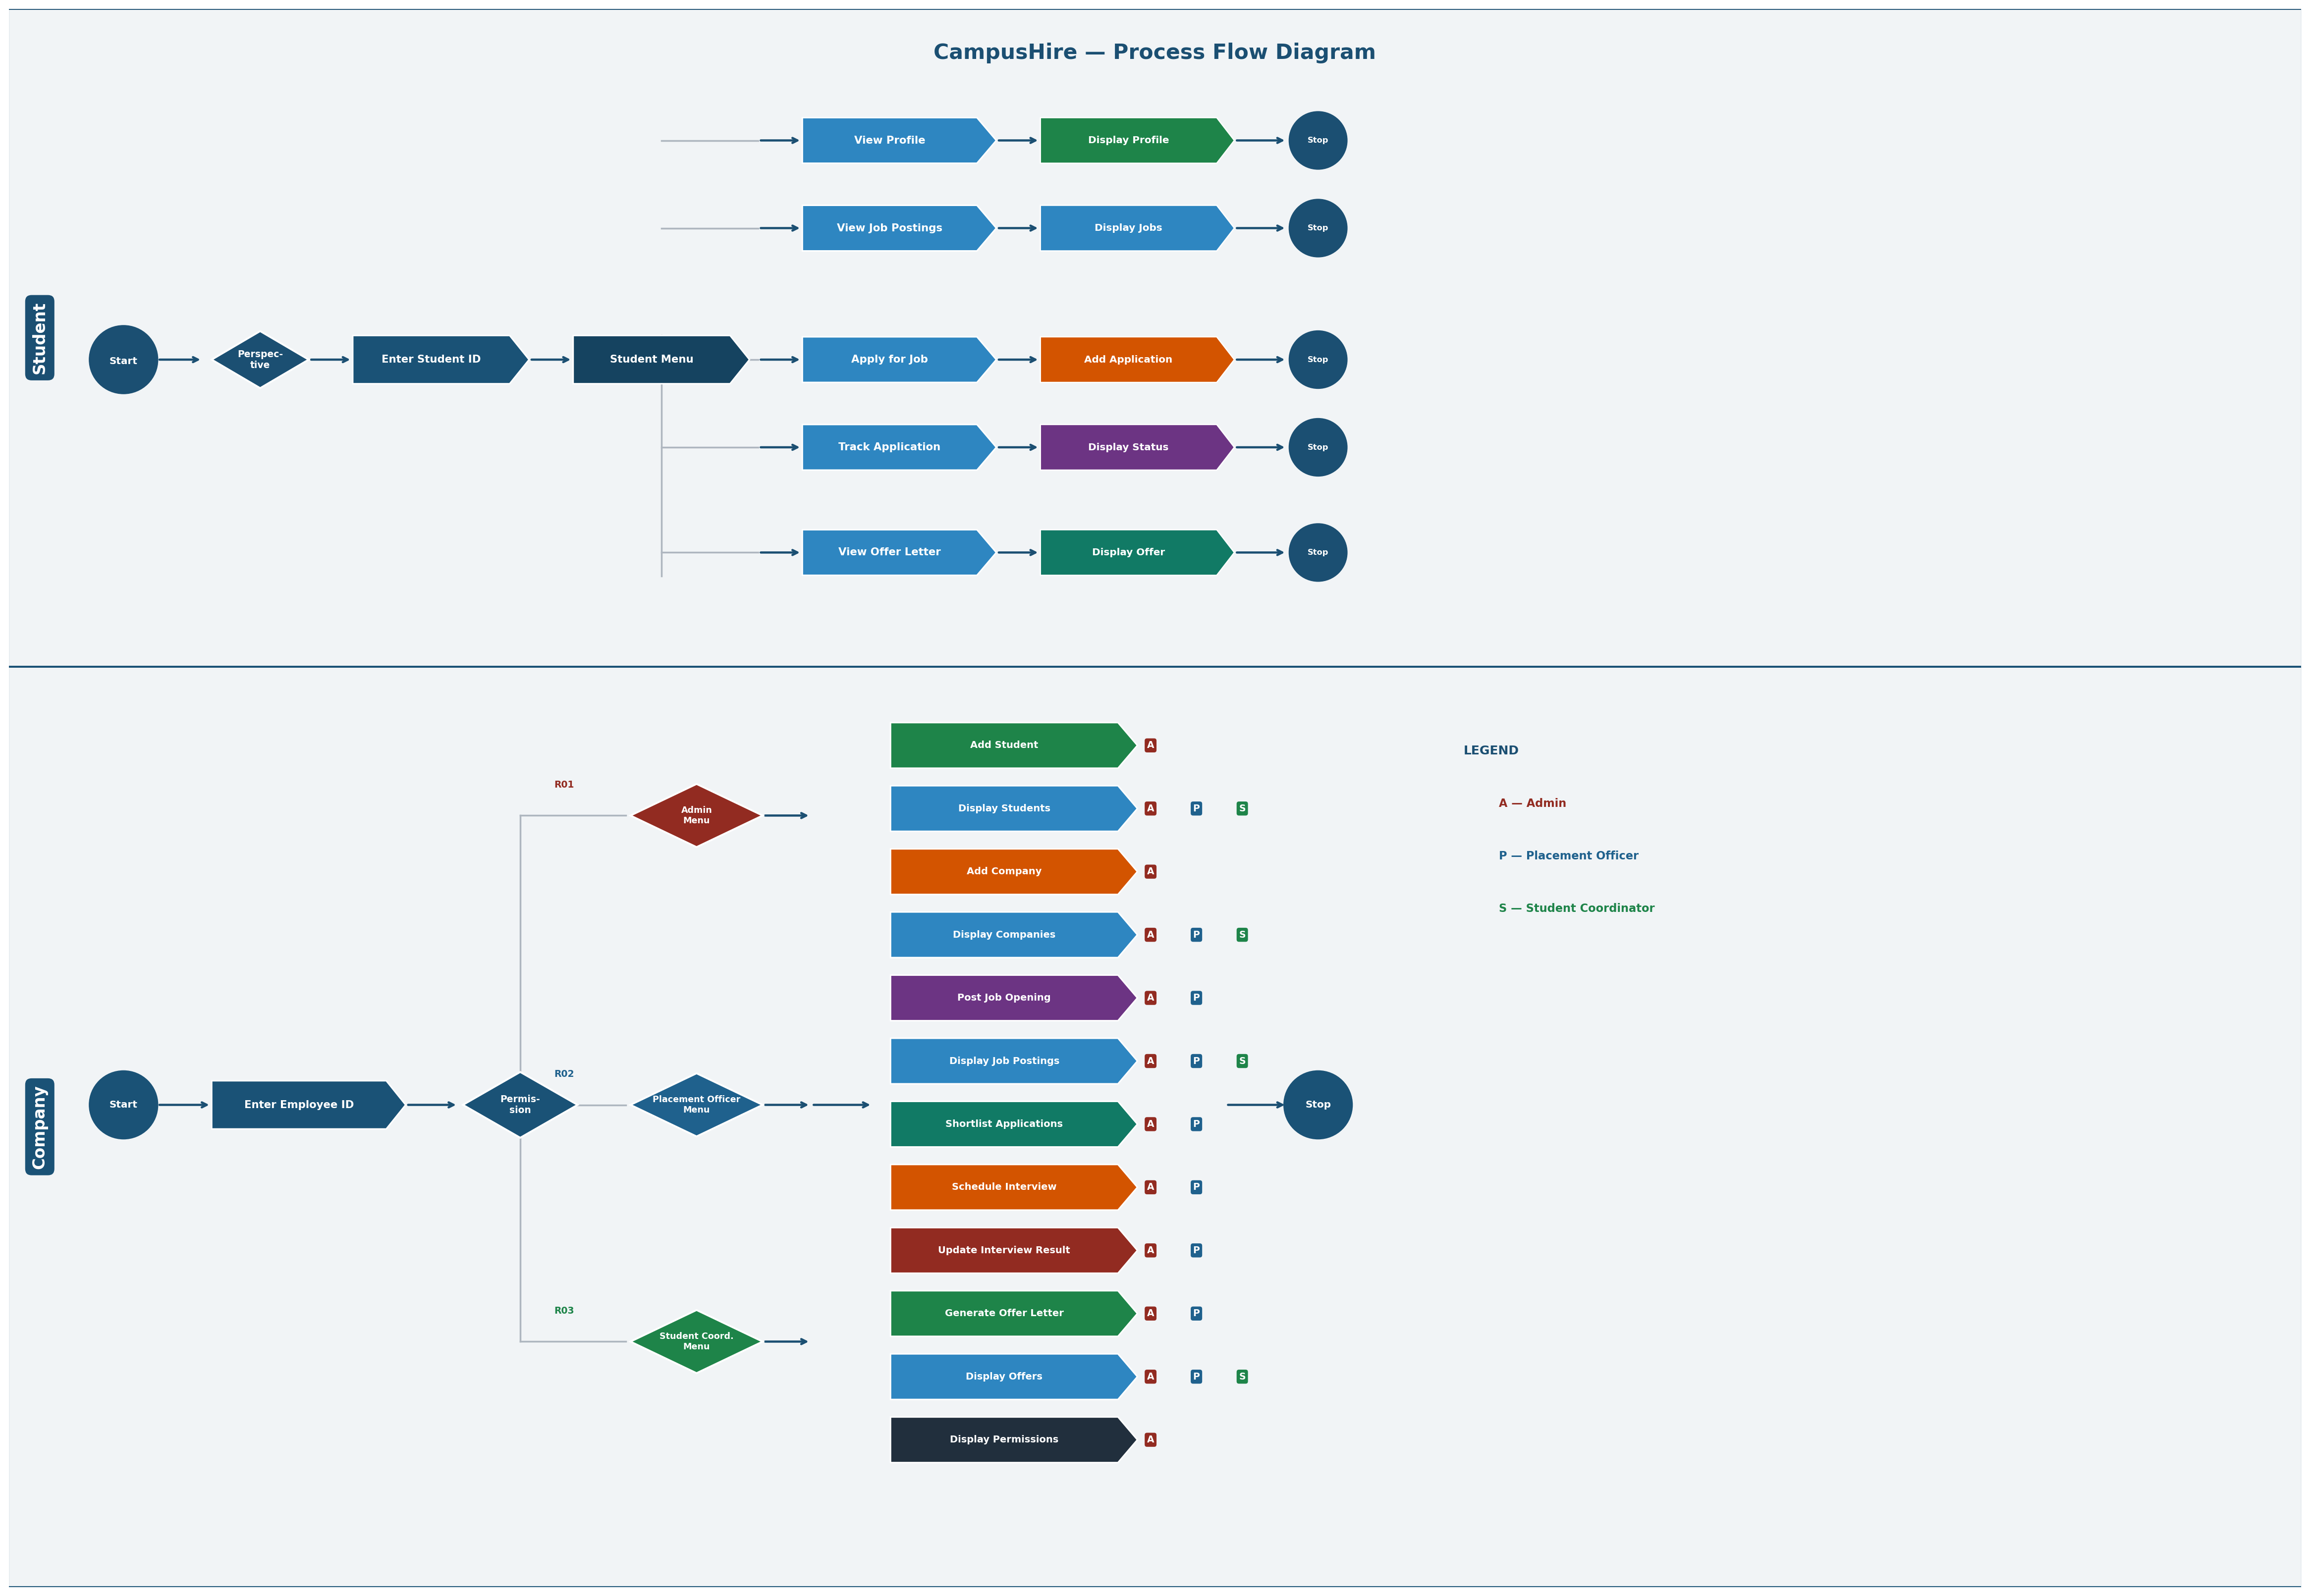

## 4. Coding - Database Tables

### 4.1 Imports and Connection

In [3]:
import mysql.connector
import random
from datetime import date

def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="604823",
        database="campushire"
    )

### 4.2 Database and Table Setup

In [4]:
def setup_database():
    conn = mysql.connector.connect(host="localhost", user="root", password="604823")
    cursor = conn.cursor()
    cursor.execute("CREATE DATABASE IF NOT EXISTS campushire")
    cursor.execute("USE campushire")
    tables = [
        """CREATE TABLE IF NOT EXISTS Permissions (role_id VARCHAR(10) PRIMARY KEY, password INT, description TEXT)""",
        """CREATE TABLE IF NOT EXISTS Student (student_id VARCHAR(15) PRIMARY KEY, name VARCHAR(100), phone VARCHAR(15), email VARCHAR(100), branch VARCHAR(50), cgpa FLOAT, status VARCHAR(30))""",
        """CREATE TABLE IF NOT EXISTS Company (company_id VARCHAR(15) PRIMARY KEY, name VARCHAR(100), industry VARCHAR(50), location VARCHAR(100), contact_email VARCHAR(100))""",
        """CREATE TABLE IF NOT EXISTS Job_Posting (job_id VARCHAR(15) PRIMARY KEY, company_id VARCHAR(15), role VARCHAR(100), required_cgpa FLOAT, package FLOAT, seats INT, FOREIGN KEY (company_id) REFERENCES Company(company_id))""",
        """CREATE TABLE IF NOT EXISTS Application (application_id VARCHAR(15) PRIMARY KEY, student_id VARCHAR(15), job_id VARCHAR(15), applied_date DATE, status VARCHAR(30), FOREIGN KEY (student_id) REFERENCES Student(student_id), FOREIGN KEY (job_id) REFERENCES Job_Posting(job_id))""",
        """CREATE TABLE IF NOT EXISTS Interview_Round (round_id VARCHAR(15) PRIMARY KEY, application_id VARCHAR(15), round_type VARCHAR(50), scheduled_date DATE, result VARCHAR(30), FOREIGN KEY (application_id) REFERENCES Application(application_id))""",
        """CREATE TABLE IF NOT EXISTS Offer_Letter (offer_id VARCHAR(15) PRIMARY KEY, student_id VARCHAR(15), company_id VARCHAR(15), package FLOAT, joining_date DATE, status VARCHAR(30), FOREIGN KEY (student_id) REFERENCES Student(student_id), FOREIGN KEY (company_id) REFERENCES Company(company_id))"""
    ]
    for t in tables:
        cursor.execute(t)
    cursor.execute("SELECT COUNT(*) FROM Permissions")
    if cursor.fetchone()[0] == 0:
        cursor.executemany("INSERT INTO Permissions VALUES (%s, %s, %s)", [
            ("R01", 123, "Admin: Full access to all features and settings."),
            ("R02", 223, "Placement Officer: Manage companies, jobs, applications and offers."),
            ("R03", 333, "Student Coordinator: View students, jobs, applications and leads."),
        ])
    conn.commit()
    cursor.close()
    conn.close()
    print("Database campushire setup complete!")

setup_database()

Database campushire setup complete!


In [5]:
def insert_sample_data():
    conn = get_connection()
    cursor = conn.cursor()

    # Students
    students = [
        ('S001', 'Aarav Sharma',    '9876543210', 'aarav@gmail.com',    'MBA', 8.5, 'Active'),
        ('S002', 'Priya Nair',      '9876543211', 'priya@gmail.com',    'MBA', 7.8, 'Active'),
        ('S003', 'Rohan Mehta',     '9876543212', 'rohan@gmail.com',    'MBA', 6.9, 'Active'),
        ('S004', 'Sneha Pillai',    '9876543213', 'sneha@gmail.com',    'MBA', 8.1, 'Active'),
        ('S005', 'Karan Verma',     '9876543214', 'karan@gmail.com',    'MBA', 7.2, 'Active'),
        ('S006', 'Ananya Reddy',    '9876543215', 'ananya@gmail.com',   'MBA', 9.0, 'Active'),
        ('S007', 'Vikram Singh',    '9876543216', 'vikram@gmail.com',   'MBA', 6.5, 'Active'),
        ('S008', 'Deepika Menon',   '9876543217', 'deepika@gmail.com',  'MBA', 8.7, 'Active'),
        ('S009', 'Arjun Patel',     '9876543218', 'arjun@gmail.com',    'MBA', 7.5, 'Active'),
        ('S010', 'Meera Iyer',      '9876543219', 'meera@gmail.com',    'MBA', 8.3, 'Active'),
    ]

    # Companies
    companies = [
        ('C001', 'Infosys',         'IT',          'Bangalore',  'hr@infosys.com'),
        ('C002', 'Deloitte',        'Consulting',  'Mumbai',     'hr@deloitte.com'),
        ('C003', 'Amazon',          'E-Commerce',  'Hyderabad',  'hr@amazon.com'),
        ('C004', 'HDFC Bank',       'Banking',     'Mumbai',     'hr@hdfc.com'),
        ('C005', 'Wipro',           'IT',          'Bangalore',  'hr@wipro.com'),
    ]

    # Job Postings
    jobs = [
        ('J001', 'C001', 'Business Analyst',        7.0, 8.5,  30),
        ('J002', 'C002', 'Management Consultant',   7.5, 12.0, 20),
        ('J003', 'C003', 'Operations Manager',      7.0, 10.0, 15),
        ('J004', 'C004', 'Relationship Manager',    6.5, 7.5,  25),
        ('J005', 'C005', 'Project Manager',         7.0, 9.0,  20),
    ]

    # Applications
    applications = [
        ('APP1001', 'S001', 'J001', '2025-01-10', 'Selected'),
        ('APP1002', 'S002', 'J002', '2025-01-11', 'Shortlisted'),
        ('APP1003', 'S003', 'J004', '2025-01-12', 'Applied'),
        ('APP1004', 'S004', 'J002', '2025-01-13', 'Selected'),
        ('APP1005', 'S005', 'J003', '2025-01-14', 'Rejected'),
        ('APP1006', 'S006', 'J001', '2025-01-15', 'Selected'),
        ('APP1007', 'S007', 'J004', '2025-01-16', 'Applied'),
        ('APP1008', 'S008', 'J005', '2025-01-17', 'Shortlisted'),
        ('APP1009', 'S009', 'J003', '2025-01-18', 'Applied'),
        ('APP1010', 'S010', 'J002', '2025-01-19', 'Shortlisted'),
    ]

    # Interview Rounds
    rounds = [
        ('RND101', 'APP1001', 'Aptitude',  '2025-01-20', 'Pass'),
        ('RND102', 'APP1002', 'Technical', '2025-01-21', 'Pass'),
        ('RND103', 'APP1004', 'HR',        '2025-01-22', 'Pass'),
        ('RND104', 'APP1006', 'Aptitude',  '2025-01-23', 'Pass'),
        ('RND105', 'APP1008', 'Technical', '2025-01-24', 'Pending'),
        ('RND106', 'APP1010', 'HR',        '2025-01-25', 'Pending'),
        ('RND107', 'APP1001', 'HR',        '2025-01-26', 'Pass'),
        ('RND108', 'APP1004', 'Technical', '2025-01-27', 'Pass'),
        ('RND109', 'APP1006', 'HR',        '2025-01-28', 'Pass'),
        ('RND110', 'APP1002', 'Aptitude',  '2025-01-29', 'Pass'),
    ]

    # Offer Letters
    offers = [
        ('OFR1001', 'S001', 'C001', 8.5,  '2025-06-01', 'Issued'),
        ('OFR1002', 'S004', 'C002', 12.0, '2025-06-01', 'Issued'),
        ('OFR1003', 'S006', 'C001', 8.5,  '2025-06-15', 'Issued'),
    ]

    try:
        cursor.executemany("INSERT IGNORE INTO Student VALUES (%s,%s,%s,%s,%s,%s,%s)", students)
        cursor.executemany("INSERT IGNORE INTO Company VALUES (%s,%s,%s,%s,%s)", companies)
        cursor.executemany("INSERT IGNORE INTO Job_Posting VALUES (%s,%s,%s,%s,%s,%s)", jobs)
        cursor.executemany("INSERT IGNORE INTO Application VALUES (%s,%s,%s,%s,%s)", applications)
        cursor.executemany("INSERT IGNORE INTO Interview_Round VALUES (%s,%s,%s,%s,%s)", rounds)
        cursor.executemany("INSERT IGNORE INTO Offer_Letter VALUES (%s,%s,%s,%s,%s,%s)", offers)
        # Mark placed students
        for offer in offers:
            cursor.execute("UPDATE Student SET status='Placed' WHERE student_id=%s", (offer[1],))
        conn.commit()
        print("Sample data inserted successfully!")
        print("10 Students | 5 Companies | 5 Job Postings | 10 Applications | 10 Interview Rounds | 3 Offer Letters")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

insert_sample_data()

Sample data inserted successfully!
10 Students | 5 Companies | 5 Job Postings | 10 Applications | 10 Interview Rounds | 3 Offer Letters


### 4.3 Permissions

In [6]:
def display_permissions():
    print("\nPERMISSIONS\n" + "-"*40)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Permissions")
    for row in cursor.fetchall():
        print(f"{row[0]} | Password: {row[1]} | {row[2]}")
    cursor.close()
    conn.close()

display_permissions()


PERMISSIONS
----------------------------------------
R01 | Password: 123 | Admin: Full access to all features and settings.
R02 | Password: 223 | Placement Officer: Manage companies, jobs, applications and offers.
R03 | Password: 333 | Student Coordinator: View students, jobs, applications and leads.


### 4.4 Student

In [8]:
def add_student():
    print("\n-- Add Student --")
    student_id = input("Enter Student ID (e.g. S001): ")
    name = input("Enter Student Name: ")
    phone = input("Enter Phone Number: ")
    email = input("Enter Email: ")
    branch = input("Enter Branch: ")
    cgpa = float(input("Enter CGPA: "))
    conn = get_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO Student VALUES (%s,%s,%s,%s,%s,%s,%s)", (student_id, name, phone, email, branch, cgpa, "Active"))
        conn.commit()
        print("Student added successfully!")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

add_student()


-- Add Student --
Student added successfully!


In [9]:
def display_students():
    print("\nSTUDENTS\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Student")
    rows = cursor.fetchall()
    if not rows: print("No students found.")
    for row in rows:
        print(f"ID: {row[0]} | Name: {row[1]} | Phone: {row[2]} | Email: {row[3]} | Branch: {row[4]} | CGPA: {row[5]} | Status: {row[6]}")
    cursor.close()
    conn.close()

display_students()


STUDENTS
------------------------------------------------------------
ID: S001 | Name: Aarav Sharma | Phone: 9876543210 | Email: aarav@gmail.com | Branch: MBA | CGPA: 8.5 | Status: Placed
ID: S002 | Name: Priya Nair | Phone: 9876543211 | Email: priya@gmail.com | Branch: MBA | CGPA: 7.8 | Status: Active
ID: S003 | Name: Rohan Mehta | Phone: 9876543212 | Email: rohan@gmail.com | Branch: MBA | CGPA: 6.9 | Status: Active
ID: S004 | Name: Sneha Pillai | Phone: 9876543213 | Email: sneha@gmail.com | Branch: MBA | CGPA: 8.1 | Status: Placed
ID: S005 | Name: Karan Verma | Phone: 9876543214 | Email: karan@gmail.com | Branch: MBA | CGPA: 7.2 | Status: Active
ID: S006 | Name: Ananya Reddy | Phone: 9876543215 | Email: ananya@gmail.com | Branch: MBA | CGPA: 9.0 | Status: Placed
ID: S007 | Name: Vikram Singh | Phone: 9876543216 | Email: vikram@gmail.com | Branch: MBA | CGPA: 6.5 | Status: Active
ID: S008 | Name: Deepika Menon | Phone: 9876543217 | Email: deepika@gmail.com | Branch: MBA | CGPA: 8.7 |

In [10]:
def update_student():
    print("\n-- Update Student --")
    student_id = input("Enter Student ID to update: ")
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Student WHERE student_id = %s", (student_id,))
    row = cursor.fetchone()
    if not row:
        print("Student not found!")
        return
    print(f"Current details: {row}")
    name = input(f"New name [{row[1]}]: ") or row[1]
    phone = input(f"New phone [{row[2]}]: ") or row[2]
    email = input(f"New email [{row[3]}]: ") or row[3]
    branch = input(f"New branch [{row[4]}]: ") or row[4]
    cgpa = input(f"New CGPA [{row[5]}]: ") or row[5]
    status = input(f"New status [{row[6]}]: ") or row[6]
    cursor.execute("UPDATE Student SET name=%s, phone=%s, email=%s, branch=%s, cgpa=%s, status=%s WHERE student_id=%s",
        (name, phone, email, branch, cgpa, status, student_id))
    conn.commit()
    print("Student updated successfully!")
    cursor.close()
    conn.close()

update_student()


-- Update Student --
Current details: ('S109', 'Diwakar', '8038367643', 'faah@gmail.com', 'MBA', 7.0, 'Active')
Student updated successfully!


In [11]:
def delete_student():
    print("\n-- Delete Student --")
    student_id = input("Enter Student ID to delete: ")
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("DELETE FROM Student WHERE student_id = %s", (student_id,))
    if cursor.rowcount:
        conn.commit()
        print("Student deleted successfully!")
    else:
        print("Student not found!")
    cursor.close()
    conn.close()

def view_student_profile(student_id):
    print("\nYour Profile\n" + "-"*40)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Student WHERE student_id = %s", (student_id,))
    row = cursor.fetchone()
    if row:
        print(f"ID      : {row[0]}")
        print(f"Name    : {row[1]}")
        print(f"Phone   : {row[2]}")
        print(f"Email   : {row[3]}")
        print(f"Branch  : {row[4]}")
        print(f"CGPA    : {row[5]}")
        print(f"Status  : {row[6]}")
    else:
        print("Student not found!")
    cursor.close()
    conn.close()

delete_student()


-- Delete Student --
Student deleted successfully!


### 4.5 Company

In [12]:
def add_company():
    print("\n-- Add Company --")
    company_id = input("Enter Company ID (e.g. C001): ")
    name = input("Enter Company Name: ")
    industry = input("Enter Industry: ")
    location = input("Enter Location: ")
    contact_email = input("Enter Contact Email: ")
    conn = get_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO Company VALUES (%s,%s,%s,%s,%s)", (company_id, name, industry, location, contact_email))
        conn.commit()
        print("Company added successfully!")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

def display_companies():
    print("\nCOMPANIES\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Company")
    rows = cursor.fetchall()
    if not rows: print("No companies found.")
    for row in rows:
        print(f"ID: {row[0]} | Name: {row[1]} | Industry: {row[2]} | Location: {row[3]} | Email: {row[4]}")
    cursor.close()
    conn.close()

add_company()


-- Add Company --
Company added successfully!


In [13]:
display_companies()


COMPANIES
------------------------------------------------------------
ID: C001 | Name: Infosys | Industry: IT | Location: Bangalore | Email: hr@infosys.com
ID: C002 | Name: Deloitte | Industry: Consulting | Location: Mumbai | Email: hr@deloitte.com
ID: C003 | Name: Amazon | Industry: E-Commerce | Location: Hyderabad | Email: hr@amazon.com
ID: C004 | Name: HDFC Bank | Industry: Banking | Location: Mumbai | Email: hr@hdfc.com
ID: C005 | Name: Wipro | Industry: IT | Location: Bangalore | Email: hr@wipro.com
ID: C009 | Name: Genpact | Industry: IT | Location: Gurgaon | Email: hr@genpact.com


### 4.6 Job Posting

In [14]:
def add_job_posting():
    print("\n-- Add Job Posting --")
    display_companies()
    job_id = input("Enter Job ID (e.g. J001): ")
    company_id = input("Enter Company ID: ")
    role = input("Enter Role/Position: ")
    required_cgpa = float(input("Enter Minimum Required CGPA: "))
    package = float(input("Enter Package (LPA): "))
    seats = int(input("Enter Number of Seats: "))
    conn = get_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO Job_Posting VALUES (%s,%s,%s,%s,%s,%s)", (job_id, company_id, role, required_cgpa, package, seats))
        conn.commit()
        print("Job Posting added successfully!")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

def display_job_postings():
    print("\nJOB POSTINGS\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT j.job_id, c.name, j.role, j.required_cgpa, j.package, j.seats FROM Job_Posting j JOIN Company c ON j.company_id = c.company_id")
    rows = cursor.fetchall()
    if not rows: print("No job postings found.")
    for row in rows:
        print(f"Job ID: {row[0]} | Company: {row[1]} | Role: {row[2]} | Min CGPA: {row[3]} | Package: {row[4]} LPA | Seats: {row[5]}")
    cursor.close()
    conn.close()

add_job_posting()


-- Add Job Posting --

COMPANIES
------------------------------------------------------------
ID: C001 | Name: Infosys | Industry: IT | Location: Bangalore | Email: hr@infosys.com
ID: C002 | Name: Deloitte | Industry: Consulting | Location: Mumbai | Email: hr@deloitte.com
ID: C003 | Name: Amazon | Industry: E-Commerce | Location: Hyderabad | Email: hr@amazon.com
ID: C004 | Name: HDFC Bank | Industry: Banking | Location: Mumbai | Email: hr@hdfc.com
ID: C005 | Name: Wipro | Industry: IT | Location: Bangalore | Email: hr@wipro.com
ID: C009 | Name: Genpact | Industry: IT | Location: Gurgaon | Email: hr@genpact.com


Job Posting added successfully!


In [15]:
display_job_postings()


JOB POSTINGS
------------------------------------------------------------
Job ID: J001 | Company: Infosys | Role: Business Analyst | Min CGPA: 7.0 | Package: 8.5 LPA | Seats: 30
Job ID: J002 | Company: Deloitte | Role: Management Consultant | Min CGPA: 7.5 | Package: 12.0 LPA | Seats: 20
Job ID: J003 | Company: Amazon | Role: Operations Manager | Min CGPA: 7.0 | Package: 10.0 LPA | Seats: 15
Job ID: J004 | Company: HDFC Bank | Role: Relationship Manager | Min CGPA: 6.5 | Package: 7.5 LPA | Seats: 25
Job ID: J005 | Company: Wipro | Role: Project Manager | Min CGPA: 7.0 | Package: 9.0 LPA | Seats: 20
Job ID: J009 | Company: Wipro | Role: HR | Min CGPA: 7.0 | Package: 9.0 LPA | Seats: 10


### 4.7 Application

In [16]:
def add_application(student_id):
    print("\n-- Apply for a Job --")
    display_job_postings()
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT cgpa FROM Student WHERE student_id = %s", (student_id,))
    student = cursor.fetchone()
    if not student:
        print("Student not found!")
        return
    job_id = input("Enter Job ID to apply: ")
    cursor.execute("SELECT required_cgpa FROM Job_Posting WHERE job_id = %s", (job_id,))
    job = cursor.fetchone()
    if not job:
        print("Job not found!")
        return
    if student[0] < job[0]:
        print(f"Sorry! Your CGPA ({student[0]}) is below the requirement ({job[0]}).")
        cursor.close()
        conn.close()
        return
    application_id = "APP" + str(random.randint(1000, 9999))
    try:
        cursor.execute("INSERT INTO Application VALUES (%s,%s,%s,%s,%s)", (application_id, student_id, job_id, date.today(), "Applied"))
        conn.commit()
        print(f"Application submitted! Your Application ID: {application_id}")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

def display_applications():
    print("\nAPPLICATIONS\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT a.application_id, s.name, j.role, c.name, a.applied_date, a.status FROM Application a JOIN Student s ON a.student_id = s.student_id JOIN Job_Posting j ON a.job_id = j.job_id JOIN Company c ON j.company_id = c.company_id")
    rows = cursor.fetchall()
    if not rows: print("No applications found.")
    for row in rows:
        print(f"App ID: {row[0]} | Student: {row[1]} | Role: {row[2]} | Company: {row[3]} | Date: {row[4]} | Status: {row[5]}")
    cursor.close()
    conn.close()

def update_application_status():
    print("\n-- Update Application Status --")
    display_applications()
    app_id = input("Enter Application ID to update: ")
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT status FROM Application WHERE application_id = %s", (app_id,))
    row = cursor.fetchone()
    if not row:
        print("Application not found!")
        return
    print(f"Current Status: {row[0]}")
    print("Statuses: Applied / Shortlisted / Interview Scheduled / Selected / Rejected")
    new_status = input("Enter new status: ")
    cursor.execute("UPDATE Application SET status=%s WHERE application_id=%s", (new_status, app_id))
    conn.commit()
    print("Application status updated!")
    cursor.close()
    conn.close()

def track_application(student_id):
    print("\nYour Applications\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT a.application_id, j.role, c.name, a.applied_date, a.status FROM Application a JOIN Job_Posting j ON a.job_id = j.job_id JOIN Company c ON j.company_id = c.company_id WHERE a.student_id = %s", (student_id,))
    rows = cursor.fetchall()
    if not rows: print("No applications found.")
    for row in rows:
        print(f"App ID: {row[0]} | Role: {row[1]} | Company: {row[2]} | Date: {row[3]} | Status: {row[4]}")
    cursor.close()
    conn.close()

add_application("S001")


-- Apply for a Job --

JOB POSTINGS
------------------------------------------------------------
Job ID: J001 | Company: Infosys | Role: Business Analyst | Min CGPA: 7.0 | Package: 8.5 LPA | Seats: 30
Job ID: J002 | Company: Deloitte | Role: Management Consultant | Min CGPA: 7.5 | Package: 12.0 LPA | Seats: 20
Job ID: J003 | Company: Amazon | Role: Operations Manager | Min CGPA: 7.0 | Package: 10.0 LPA | Seats: 15
Job ID: J004 | Company: HDFC Bank | Role: Relationship Manager | Min CGPA: 6.5 | Package: 7.5 LPA | Seats: 25
Job ID: J005 | Company: Wipro | Role: Project Manager | Min CGPA: 7.0 | Package: 9.0 LPA | Seats: 20
Job ID: J009 | Company: Wipro | Role: HR | Min CGPA: 7.0 | Package: 9.0 LPA | Seats: 10
Application submitted! Your Application ID: APP7163


In [17]:
display_applications()


APPLICATIONS
------------------------------------------------------------
App ID: APP1001 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2025-01-10 | Status: Selected
App ID: APP1006 | Student: Ananya Reddy | Role: Business Analyst | Company: Infosys | Date: 2025-01-15 | Status: Selected
App ID: APP7163 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2026-03-04 | Status: Applied
App ID: APP1002 | Student: Priya Nair | Role: Management Consultant | Company: Deloitte | Date: 2025-01-11 | Status: Shortlisted
App ID: APP1004 | Student: Sneha Pillai | Role: Management Consultant | Company: Deloitte | Date: 2025-01-13 | Status: Selected
App ID: APP1010 | Student: Meera Iyer | Role: Management Consultant | Company: Deloitte | Date: 2025-01-19 | Status: Shortlisted
App ID: APP1005 | Student: Karan Verma | Role: Operations Manager | Company: Amazon | Date: 2025-01-14 | Status: Rejected
App ID: APP1009 | Student: Arjun Patel | Role: Opera

In [19]:
update_application_status()


-- Update Application Status --

APPLICATIONS
------------------------------------------------------------
App ID: APP1001 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2025-01-10 | Status: Selected
App ID: APP1006 | Student: Ananya Reddy | Role: Business Analyst | Company: Infosys | Date: 2025-01-15 | Status: Selected
App ID: APP7163 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2026-03-04 | Status: Rejected
App ID: APP1002 | Student: Priya Nair | Role: Management Consultant | Company: Deloitte | Date: 2025-01-11 | Status: Shortlisted
App ID: APP1004 | Student: Sneha Pillai | Role: Management Consultant | Company: Deloitte | Date: 2025-01-13 | Status: Selected
App ID: APP1010 | Student: Meera Iyer | Role: Management Consultant | Company: Deloitte | Date: 2025-01-19 | Status: Shortlisted
App ID: APP1005 | Student: Karan Verma | Role: Operations Manager | Company: Amazon | Date: 2025-01-14 | Status: Rejected
App ID: APP1009 | 

Current Status: Rejected
Statuses: Applied / Shortlisted / Interview Scheduled / Selected / Rejected
Application status updated!


### 4.8 Interview Round

In [20]:
def add_interview_round():
    print("\n-- Schedule Interview Round --")
    display_applications()
    round_id = "RND" + str(random.randint(100, 999))
    application_id = input("Enter Application ID: ")
    round_type = input("Enter Round Type (Aptitude/Technical/HR/Group Discussion): ")
    scheduled_date = input("Enter Scheduled Date (YYYY-MM-DD): ")
    conn = get_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO Interview_Round VALUES (%s,%s,%s,%s,%s)", (round_id, application_id, round_type, scheduled_date, "Pending"))
        conn.commit()
        print(f"Interview Round scheduled! Round ID: {round_id}")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

def display_interview_rounds():
    print("\nINTERVIEW ROUNDS\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT ir.round_id, s.name, j.role, ir.round_type, ir.scheduled_date, ir.result FROM Interview_Round ir JOIN Application a ON ir.application_id = a.application_id JOIN Student s ON a.student_id = s.student_id JOIN Job_Posting j ON a.job_id = j.job_id")
    rows = cursor.fetchall()
    if not rows: print("No interview rounds found.")
    for row in rows:
        print(f"Round ID: {row[0]} | Student: {row[1]} | Role: {row[2]} | Type: {row[3]} | Date: {row[4]} | Result: {row[5]}")
    cursor.close()
    conn.close()

def update_interview_result():
    print("\n-- Update Interview Result --")
    display_interview_rounds()
    round_id = input("Enter Round ID to update: ")
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT result FROM Interview_Round WHERE round_id = %s", (round_id,))
    row = cursor.fetchone()
    if not row:
        print("Round not found!")
        return
    print(f"Current Result: {row[0]}")
    result = input("Enter new result (Pass / Fail / Pending): ")
    cursor.execute("UPDATE Interview_Round SET result=%s WHERE round_id=%s", (result, round_id))
    conn.commit()
    print("Interview result updated!")
    cursor.close()
    conn.close()

add_interview_round()


-- Schedule Interview Round --

APPLICATIONS
------------------------------------------------------------
App ID: APP1001 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2025-01-10 | Status: Selected
App ID: APP1006 | Student: Ananya Reddy | Role: Business Analyst | Company: Infosys | Date: 2025-01-15 | Status: Selected
App ID: APP7163 | Student: Aarav Sharma | Role: Business Analyst | Company: Infosys | Date: 2026-03-04 | Status: Shortlisted
App ID: APP1002 | Student: Priya Nair | Role: Management Consultant | Company: Deloitte | Date: 2025-01-11 | Status: Shortlisted
App ID: APP1004 | Student: Sneha Pillai | Role: Management Consultant | Company: Deloitte | Date: 2025-01-13 | Status: Selected
App ID: APP1010 | Student: Meera Iyer | Role: Management Consultant | Company: Deloitte | Date: 2025-01-19 | Status: Shortlisted
App ID: APP1005 | Student: Karan Verma | Role: Operations Manager | Company: Amazon | Date: 2025-01-14 | Status: Rejected
App ID: APP1009 

Interview Round scheduled! Round ID: RND180


In [21]:
display_interview_rounds()


INTERVIEW ROUNDS
------------------------------------------------------------
Round ID: RND101 | Student: Aarav Sharma | Role: Business Analyst | Type: Aptitude | Date: 2025-01-20 | Result: Pass
Round ID: RND102 | Student: Priya Nair | Role: Management Consultant | Type: Technical | Date: 2025-01-21 | Result: Pass
Round ID: RND103 | Student: Sneha Pillai | Role: Management Consultant | Type: HR | Date: 2025-01-22 | Result: Pass
Round ID: RND104 | Student: Ananya Reddy | Role: Business Analyst | Type: Aptitude | Date: 2025-01-23 | Result: Pass
Round ID: RND105 | Student: Deepika Menon | Role: Project Manager | Type: Technical | Date: 2025-01-24 | Result: Pending
Round ID: RND106 | Student: Meera Iyer | Role: Management Consultant | Type: HR | Date: 2025-01-25 | Result: Pending
Round ID: RND107 | Student: Aarav Sharma | Role: Business Analyst | Type: HR | Date: 2025-01-26 | Result: Pass
Round ID: RND108 | Student: Sneha Pillai | Role: Management Consultant | Type: Technical | Date: 2025

In [22]:
update_interview_result()


-- Update Interview Result --

INTERVIEW ROUNDS
------------------------------------------------------------
Round ID: RND101 | Student: Aarav Sharma | Role: Business Analyst | Type: Aptitude | Date: 2025-01-20 | Result: Pass
Round ID: RND102 | Student: Priya Nair | Role: Management Consultant | Type: Technical | Date: 2025-01-21 | Result: Pass
Round ID: RND103 | Student: Sneha Pillai | Role: Management Consultant | Type: HR | Date: 2025-01-22 | Result: Pass
Round ID: RND104 | Student: Ananya Reddy | Role: Business Analyst | Type: Aptitude | Date: 2025-01-23 | Result: Pass
Round ID: RND105 | Student: Deepika Menon | Role: Project Manager | Type: Technical | Date: 2025-01-24 | Result: Pending
Round ID: RND106 | Student: Meera Iyer | Role: Management Consultant | Type: HR | Date: 2025-01-25 | Result: Pending
Round ID: RND107 | Student: Aarav Sharma | Role: Business Analyst | Type: HR | Date: 2025-01-26 | Result: Pass
Round ID: RND108 | Student: Sneha Pillai | Role: Management Consultant

Current Result: Pending
Interview result updated!


### 4.9 Offer Letter

In [26]:
def generate_offer_letter():
    print("\n-- Generate Offer Letter --")
    display_students()
    display_companies()
    offer_id = "OFR" + str(random.randint(1000, 9999))
    student_id = input("Enter Student ID: ")
    company_id = input("Enter Company ID: ")
    package = float(input("Enter Offered Package (LPA): "))
    joining_date = input("Enter Joining Date (YYYY-MM-DD): ")
    conn = get_connection()
    cursor = conn.cursor()
    try:
        cursor.execute("INSERT INTO Offer_Letter VALUES (%s,%s,%s,%s,%s,%s)", (offer_id, student_id, company_id, package, joining_date, "Issued"))
        cursor.execute("UPDATE Student SET status='Placed' WHERE student_id=%s", (student_id,))
        conn.commit()
        print(f"Offer Letter generated! Offer ID: {offer_id}")
        print("Student status updated to Placed!")
    except mysql.connector.Error as e:
        print(f"Error: {e}")
    finally:
        cursor.close()
        conn.close()

def display_offer_letters():
    print("\nOFFER LETTERS\n" + "-"*60)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT o.offer_id, s.name, c.name, o.package, o.joining_date, o.status FROM Offer_Letter o JOIN Student s ON o.student_id = s.student_id JOIN Company c ON o.company_id = c.company_id")
    rows = cursor.fetchall()
    if not rows: print("No offer letters found.")
    for row in rows:
        print(f"Offer ID: {row[0]} | Student: {row[1]} | Company: {row[2]} | Package: {row[3]} LPA | Joining: {row[4]} | Status: {row[5]}")
    cursor.close()
    conn.close()

def view_my_offer(student_id):
    print("\nYour Offer Letter\n" + "-"*40)
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT o.offer_id, c.name, o.package, o.joining_date, o.status FROM Offer_Letter o JOIN Company c ON o.company_id = c.company_id WHERE o.student_id = %s", (student_id,))
    row = cursor.fetchone()
    if row:
        print(f"Offer ID     : {row[0]}")
        print(f"Company      : {row[1]}")
        print(f"Package      : {row[2]} LPA")
        print(f"Joining Date : {row[3]}")
        print(f"Status       : {row[4]}")
    else:
        print("No offer letter found yet.")
    cursor.close()
    conn.close()

generate_offer_letter()


-- Generate Offer Letter --

STUDENTS
------------------------------------------------------------
ID: S001 | Name: Aarav Sharma | Phone: 9876543210 | Email: aarav@gmail.com | Branch: MBA | CGPA: 8.5 | Status: Placed
ID: S002 | Name: Priya Nair | Phone: 9876543211 | Email: priya@gmail.com | Branch: MBA | CGPA: 7.8 | Status: Active
ID: S003 | Name: Rohan Mehta | Phone: 9876543212 | Email: rohan@gmail.com | Branch: MBA | CGPA: 6.9 | Status: Active
ID: S004 | Name: Sneha Pillai | Phone: 9876543213 | Email: sneha@gmail.com | Branch: MBA | CGPA: 8.1 | Status: Placed
ID: S005 | Name: Karan Verma | Phone: 9876543214 | Email: karan@gmail.com | Branch: MBA | CGPA: 7.2 | Status: Active
ID: S006 | Name: Ananya Reddy | Phone: 9876543215 | Email: ananya@gmail.com | Branch: MBA | CGPA: 9.0 | Status: Placed
ID: S007 | Name: Vikram Singh | Phone: 9876543216 | Email: vikram@gmail.com | Branch: MBA | CGPA: 6.5 | Status: Active
ID: S008 | Name: Deepika Menon | Phone: 9876543217 | Email: deepika@gmail.co

In [27]:
display_offer_letters()


OFFER LETTERS
------------------------------------------------------------
Offer ID: OFR1001 | Student: Aarav Sharma | Company: Infosys | Package: 8.5 LPA | Joining: 2025-06-01 | Status: Issued
Offer ID: OFR1002 | Student: Sneha Pillai | Company: Deloitte | Package: 12.0 LPA | Joining: 2025-06-01 | Status: Issued
Offer ID: OFR1003 | Student: Ananya Reddy | Company: Infosys | Package: 8.5 LPA | Joining: 2025-06-15 | Status: Issued
Offer ID: OFR9321 | Student: Vikram Singh | Company: Infosys | Package: 9.5 LPA | Joining: 2025-07-01 | Status: Issued


## 5. Coding - MENU

### 5.1 Student Menu

In [28]:
def student_menu():
    print("\nWelcome to CampusHire\n")
    student_id = input("Please enter your Student ID: ")
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM Student WHERE student_id = %s", (student_id,))
    row = cursor.fetchone()
    cursor.close()
    conn.close()
    if not row:
        print("Student not found!")
        return
    print(f"\nHey {row[0]}, welcome back!\n")
    print("What do you want to do?\n" + "-"*30)
    print("1. View my profile")
    print("2. View job postings")
    print("3. Apply for a job")
    print("4. Track my applications")
    print("5. View my offer letter")
    go_on = "yes"
    while go_on == "yes":
        choice = int(input("\nEnter your choice: "))
        if   choice == 1: view_student_profile(student_id)
        elif choice == 2: display_job_postings()
        elif choice == 3: add_application(student_id)
        elif choice == 4: track_application(student_id)
        elif choice == 5: view_my_offer(student_id)
        else: print("Invalid entry!")
        go_on = input("\nContinue with the menu? (yes/no): ").lower()

student_menu()


Welcome to CampusHire


Hey Aarav Sharma, welcome back!

What do you want to do?
------------------------------
1. View my profile
2. View job postings
3. Apply for a job
4. Track my applications
5. View my offer letter

Your Profile
----------------------------------------
ID      : S001
Name    : Aarav Sharma
Phone   : 9876543210
Email   : aarav@gmail.com
Branch  : MBA
CGPA    : 8.5
Status  : Placed


### 5.2 Company Menu

In [29]:
def company_menu():
    print("\nWelcome to CampusHire\n")
    emp_id = input("Please enter your Employee ID: ")
    password = int(input("Enter your password: "))
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Permissions WHERE role_id = %s AND password = %s", (emp_id, password))
    role = cursor.fetchone()
    cursor.close()
    conn.close()
    if not role:
        print("Invalid credentials!")
        return
    role_id = role[0]
    print(f"\nLogged in as: {role[2]}\n")
    if role_id == "R01":
        print("Role: Admin\nWhat would you like to do?\n" + "-"*40)
        print("\nStudent Functions:")
        print("1.  Add a new student")
        print("2.  Display all students")
        print("3.  Update a student")
        print("4.  Delete a student")
        print("\nCompany Functions:")
        print("5.  Add a new company")
        print("6.  Display all companies")
        print("\nJob Posting Functions:")
        print("7.  Add a new job posting")
        print("8.  Display all job postings")
        print("\nApplication Functions:")
        print("9.  Display all applications")
        print("10. Update application status")
        print("\nInterview Round Functions:")
        print("11. Schedule an interview round")
        print("12. Display all interview rounds")
        print("13. Update interview result")
        print("\nOffer Letter Functions:")
        print("14. Generate offer letter")
        print("15. Display all offer letters")
        print("\nPermissions:")
        print("16. Display all permissions")
        print("\n17. Display ALL records")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1:  add_student()
            elif choice == 2:  display_students()
            elif choice == 3:  update_student()
            elif choice == 4:  delete_student()
            elif choice == 5:  add_company()
            elif choice == 6:  display_companies()
            elif choice == 7:  add_job_posting()
            elif choice == 8:  display_job_postings()
            elif choice == 9:  display_applications()
            elif choice == 10: update_application_status()
            elif choice == 11: add_interview_round()
            elif choice == 12: display_interview_rounds()
            elif choice == 13: update_interview_result()
            elif choice == 14: generate_offer_letter()
            elif choice == 15: display_offer_letters()
            elif choice == 16: display_permissions()
            elif choice == 17:
                display_students(); display_companies(); display_job_postings()
                display_applications(); display_interview_rounds()
                display_offer_letters(); display_permissions()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()
    elif role_id == "R02":
        print("Role: Placement Officer\nWhat would you like to do?\n" + "-"*40)
        print("1.  Display all students"); print("2.  Add a new company"); print("3.  Display all companies")
        print("4.  Add a new job posting"); print("5.  Display all job postings"); print("6.  Display all applications")
        print("7.  Update application status"); print("8.  Schedule an interview round"); print("9.  Display all interview rounds")
        print("10. Update interview result"); print("11. Generate offer letter"); print("12. Display all offer letters")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1:  display_students()
            elif choice == 2:  add_company()
            elif choice == 3:  display_companies()
            elif choice == 4:  add_job_posting()
            elif choice == 5:  display_job_postings()
            elif choice == 6:  display_applications()
            elif choice == 7:  update_application_status()
            elif choice == 8:  add_interview_round()
            elif choice == 9:  display_interview_rounds()
            elif choice == 10: update_interview_result()
            elif choice == 11: generate_offer_letter()
            elif choice == 12: display_offer_letters()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()
    elif role_id == "R03":
        print("Role: Student Coordinator\nWhat would you like to do?\n" + "-"*40)
        print("1. Display all students"); print("2. Display all companies"); print("3. Display all job postings")
        print("4. Display all applications"); print("5. Display all interview rounds"); print("6. Display all offer letters")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1: display_students()
            elif choice == 2: display_companies()
            elif choice == 3: display_job_postings()
            elif choice == 4: display_applications()
            elif choice == 5: display_interview_rounds()
            elif choice == 6: display_offer_letters()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()

company_menu()  # Admin: R01/123  |  Placement Officer: R02/223  |  Coordinator: R03/333


Welcome to CampusHire


Logged in as: Admin: Full access to all features and settings.

Role: Admin
What would you like to do?
----------------------------------------

Student Functions:
1.  Add a new student
2.  Display all students
3.  Update a student
4.  Delete a student

Company Functions:
5.  Add a new company
6.  Display all companies

Job Posting Functions:
7.  Add a new job posting
8.  Display all job postings

Application Functions:
9.  Display all applications
10. Update application status

Interview Round Functions:
11. Schedule an interview round
12. Display all interview rounds
13. Update interview result

Offer Letter Functions:
14. Generate offer letter
15. Display all offer letters

Permissions:
16. Display all permissions

17. Display ALL records

STUDENTS
------------------------------------------------------------
ID: S001 | Name: Aarav Sharma | Phone: 9876543210 | Email: aarav@gmail.com | Branch: MBA | CGPA: 8.5 | Status: Placed
ID: S002 | Name: Priya Nair | Phon

### 5.3 Master Menu

**Run this cell to launch CampusHire**

In [31]:
def company_menu():
    print("\nWelcome to CampusHire\n")
    emp_id = input("Please enter your Employee ID: ")
    password = int(input("Enter your password: "))
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM Permissions WHERE role_id = %s AND password = %s", (emp_id, password))
    role = cursor.fetchone()
    cursor.close()
    conn.close()
    if not role:
        print("Invalid credentials!")
        return
    role_id = role[0]
    print(f"\nLogged in as: {role[2]}\n")
    if role_id == "R01":
        print("Role: Admin\nWhat would you like to do?\n" + "-"*40)
        print("\nStudent Functions:")
        print("1.  Add a new student")
        print("2.  Display all students")
        print("3.  Update a student")
        print("4.  Delete a student")
        print("\nCompany Functions:")
        print("5.  Add a new company")
        print("6.  Display all companies")
        print("\nJob Posting Functions:")
        print("7.  Add a new job posting")
        print("8.  Display all job postings")
        print("\nApplication Functions:")
        print("9.  Display all applications")
        print("10. Update application status")
        print("\nInterview Round Functions:")
        print("11. Schedule an interview round")
        print("12. Display all interview rounds")
        print("13. Update interview result")
        print("\nOffer Letter Functions:")
        print("14. Generate offer letter")
        print("15. Display all offer letters")
        print("\nPermissions:")
        print("16. Display all permissions")
        print("\n17. Display ALL records")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1:  add_student()
            elif choice == 2:  display_students()
            elif choice == 3:  update_student()
            elif choice == 4:  delete_student()
            elif choice == 5:  add_company()
            elif choice == 6:  display_companies()
            elif choice == 7:  add_job_posting()
            elif choice == 8:  display_job_postings()
            elif choice == 9:  display_applications()
            elif choice == 10: update_application_status()
            elif choice == 11: add_interview_round()
            elif choice == 12: display_interview_rounds()
            elif choice == 13: update_interview_result()
            elif choice == 14: generate_offer_letter()
            elif choice == 15: display_offer_letters()
            elif choice == 16: display_permissions()
            elif choice == 17:
                display_students(); display_companies(); display_job_postings()
                display_applications(); display_interview_rounds()
                display_offer_letters(); display_permissions()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()
    elif role_id == "R02":
        print("Role: Placement Officer\nWhat would you like to do?\n" + "-"*40)
        print("1.  Display all students"); print("2.  Add a new company"); print("3.  Display all companies")
        print("4.  Add a new job posting"); print("5.  Display all job postings"); print("6.  Display all applications")
        print("7.  Update application status"); print("8.  Schedule an interview round"); print("9.  Display all interview rounds")
        print("10. Update interview result"); print("11. Generate offer letter"); print("12. Display all offer letters")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1:  display_students()
            elif choice == 2:  add_company()
            elif choice == 3:  display_companies()
            elif choice == 4:  add_job_posting()
            elif choice == 5:  display_job_postings()
            elif choice == 6:  display_applications()
            elif choice == 7:  update_application_status()
            elif choice == 8:  add_interview_round()
            elif choice == 9:  display_interview_rounds()
            elif choice == 10: update_interview_result()
            elif choice == 11: generate_offer_letter()
            elif choice == 12: display_offer_letters()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()
    elif role_id == "R03":
        print("Role: Student Coordinator\nWhat would you like to do?\n" + "-"*40)
        print("1. Display all students"); print("2. Display all companies"); print("3. Display all job postings")
        print("4. Display all applications"); print("5. Display all interview rounds"); print("6. Display all offer letters")
        go_on = "yes"
        while go_on == "yes":
            choice = int(input("\nEnter your choice: "))
            if   choice == 1: display_students()
            elif choice == 2: display_companies()
            elif choice == 3: display_job_postings()
            elif choice == 4: display_applications()
            elif choice == 5: display_interview_rounds()
            elif choice == 6: display_offer_letters()
            else: print("Invalid entry!")
            go_on = input("\nContinue with the menu? (yes/no): ").lower()

company_menu()  # Admin: R01/123  |  Placement Officer: R02/223  |  Coordinator: R03/333


Welcome to CampusHire


Logged in as: Admin: Full access to all features and settings.

Role: Admin
What would you like to do?
----------------------------------------

Student Functions:
1.  Add a new student
2.  Display all students
3.  Update a student
4.  Delete a student

Company Functions:
5.  Add a new company
6.  Display all companies

Job Posting Functions:
7.  Add a new job posting
8.  Display all job postings

Application Functions:
9.  Display all applications
10. Update application status

Interview Round Functions:
11. Schedule an interview round
12. Display all interview rounds
13. Update interview result

Offer Letter Functions:
14. Generate offer letter
15. Display all offer letters

Permissions:
16. Display all permissions

17. Display ALL records

COMPANIES
------------------------------------------------------------
ID: C001 | Name: Infosys | Industry: IT | Location: Bangalore | Email: hr@infosys.com
ID: C002 | Name: Deloitte | Industry: Consulting | Location: Mumb

In [32]:
def run():
    setup_database()
    print("=" * 50)
    print("       Welcome to CampusHire")
    print("   Campus Placement Management System")
    print("=" * 50)
    print("\n1. Company / Staff Login")
    print("2. Student Login")
    choice = int(input("\nEnter your choice: "))
    if   choice == 1: company_menu()
    elif choice == 2: student_menu()
    else: print("Invalid entry!")

run()

Database campushire setup complete!
       Welcome to CampusHire
   Campus Placement Management System

1. Company / Staff Login
2. Student Login

Welcome to CampusHire


Hey Aarav Sharma, welcome back!

What do you want to do?
------------------------------
1. View my profile
2. View job postings
3. Apply for a job
4. Track my applications
5. View my offer letter

Your Applications
------------------------------------------------------------
App ID: APP1001 | Role: Business Analyst | Company: Infosys | Date: 2025-01-10 | Status: Selected
App ID: APP7163 | Role: Business Analyst | Company: Infosys | Date: 2026-03-04 | Status: Shortlisted
